# Capstone Feasibility EDA: When Severity Does Not Equal Risk

This notebook is an **initial feasibility check** for the proposed capstone:

> **How often does severity-based vulnerability prioritization under-prioritize vulnerabilities known to be exploited, what characteristics are associated with these mismatches, and have these patterns changed over time?**

It combines:
- **NVD CVE data (2020–2026)** for CVSS scores and vulnerability characteristics
- **CISA Known Exploited Vulnerabilities (KEV)** for confirmed known exploitation
- **EPSS** for a current probability-of-exploitation comparison

### Methodological safeguards
- KEV presence is treated as evidence of known exploitation; **KEV absence is not treated as proof that a vulnerability was never exploited**.
- **2026 is an incomplete study year** and should be interpreted separately.
- The source-file year, CVE-ID year, and actual NVD publication year are stored separately.
- CVSS versions are tracked explicitly.
- CVSS v3.x characteristics are used for like-for-like categorical statistical comparisons.
- The available EPSS file is a **current snapshot**, not historical EPSS.


In [1]:
# Imports and project paths
# Imports and project paths
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)

# ---------------------------------------------------------
# Locate the DATA 698 capstone project root
# ---------------------------------------------------------

cwd = Path.cwd().resolve()

if (cwd / "data").exists() and (cwd / "notebooks").exists():
    # Jupyter was launched from the repository root
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "data").exists():
    # Jupyter is running from the notebooks folder
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the data698-capstone project root."
    )

# Project folders
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

# Make sure output folders exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Years included in the analysis
YEARS = list(range(2020, 2027))

# Raw source files
KEV_FILE = RAW_DATA_DIR / "known_exploited_vulnerabilities.csv"
EPSS_FILE = RAW_DATA_DIR / "epss_scores-2026-09-02.csv.gz"

# Verify project paths
print("Working directory:", cwd)
print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)

print("\nKEV file exists:", KEV_FILE.exists())
print("EPSS file exists:", EPSS_FILE.exists())


Working directory: /Users/aaliyahmjh/Documents/data698-capstone/notebooks
Project root: /Users/aaliyahmjh/Documents/data698-capstone
Raw data directory: /Users/aaliyahmjh/Documents/data698-capstone/data/raw
Processed data directory: /Users/aaliyahmjh/Documents/data698-capstone/data/processed
Figures directory: /Users/aaliyahmjh/Documents/data698-capstone/figures
Results directory: /Users/aaliyahmjh/Documents/data698-capstone/results

KEV file exists: True
EPSS file exists: True


## 1. Validate the input files

The notebook first checks that all seven NVD ZIP files are present before loading anything. This prevents a partial analysis from silently running with missing years.


In [2]:
def find_nvd_zip(year):
    preferred = RAW_DATA_DIR / f"nvdcve-2.0-{year}.json.zip"

    if preferred.exists():
        return preferred

    # Allows browser-renamed copies such as "...2020.json (1).zip".
    matches = sorted(RAW_DATA_DIR.glob(f"*{year}*.json.zip"))

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise ValueError(
            f"Multiple possible NVD files found for {year}: "
            f"{[p.name for p in matches]}"
        )

    raise FileNotFoundError(
        f"No NVD 2.0 ZIP found for {year} in {RAW_DATA_DIR.resolve()}"
    )


missing_years = []

for year in YEARS:
    try:
        path = find_nvd_zip(year)
        print(f"✓ {year}: {path.name}")
    except FileNotFoundError:
        missing_years.append(year)
        print(f"✗ {year}: MISSING")

if missing_years:
    raise FileNotFoundError(
        f"Missing NVD files for: {missing_years}. "
        "Add them to the notebook folder before continuing."
    )

if not KEV_FILE.exists():
    raise FileNotFoundError(f"Missing KEV file: {KEV_FILE.resolve()}")

if not EPSS_FILE.exists():
    raise FileNotFoundError(f"Missing EPSS file: {EPSS_FILE.resolve()}")


✓ 2020: nvdcve-2.0-2020.json.zip
✓ 2021: nvdcve-2.0-2021.json.zip
✓ 2022: nvdcve-2.0-2022.json.zip
✓ 2023: nvdcve-2.0-2023.json.zip
✓ 2024: nvdcve-2.0-2024.json.zip
✓ 2025: nvdcve-2.0-2025.json.zip
✓ 2026: nvdcve-2.0-2026.json.zip


## 2. Define NVD extraction functions

NVD JSON is nested, so this section extracts only the fields needed for the study.

### CVSS selection rule
For comparability across 2020–2026, the notebook prefers:
1. CVSS v3.1
2. CVSS v3.0
3. CVSS v4.0
4. CVSS v2 as a last fallback

The selected version is retained in `cvss_version`. Later categorical statistical analyses are restricted to **CVSS v3.x** so categories from different CVSS versions are not mixed as though they were identical.


In [3]:
def choose_metric(metrics):
    preference = [
        ("cvssMetricV31", "3.1"),
        ("cvssMetricV30", "3.0"),
        ("cvssMetricV40", "4.0"),
        ("cvssMetricV2", "2.0"),
    ]

    for key, version in preference:
        entries = metrics.get(key, [])
        if not entries:
            continue

        # Prefer NVD's assessment, then a Primary assessment, then first available.
        chosen = next(
            (x for x in entries if x.get("source") == "nvd@nist.gov"),
            None
        )
        if chosen is None:
            chosen = next(
                (x for x in entries if x.get("type") == "Primary"),
                None
            )
        if chosen is None:
            chosen = entries[0]

        d = chosen.get("cvssData", {})

        return {
            "cvss_version": str(d.get("version", version)),
            "cvss_source": chosen.get("source"),
            "cvss_type": chosen.get("type"),
            "cvss_score": d.get("baseScore"),
            "cvss_severity": d.get("baseSeverity") or chosen.get("baseSeverity"),
            "attack_vector": d.get("attackVector") or d.get("accessVector"),
            "attack_complexity": d.get("attackComplexity") or d.get("accessComplexity"),
            "privileges_required": d.get("privilegesRequired"),
            "user_interaction": d.get("userInteraction"),
            "confidentiality_impact": d.get("confidentialityImpact"),
            "integrity_impact": d.get("integrityImpact"),
            "availability_impact": d.get("availabilityImpact"),
        }

    return {
        "cvss_version": None,
        "cvss_source": None,
        "cvss_type": None,
        "cvss_score": None,
        "cvss_severity": None,
        "attack_vector": None,
        "attack_complexity": None,
        "privileges_required": None,
        "user_interaction": None,
        "confidentiality_impact": None,
        "integrity_impact": None,
        "availability_impact": None,
    }


def extract_cwes(cve):
    vals = []

    for weakness in cve.get("weaknesses", []):
        for desc in weakness.get("description", []):
            val = desc.get("value")
            if val and str(val).startswith("CWE-"):
                vals.append(val)

    return list(dict.fromkeys(vals))


def extract_vendors_products(cve):
    vendors, products = [], []

    def walk_node(node):
        for match in node.get("cpeMatch", []):
            if not match.get("vulnerable", False):
                continue

            criteria = match.get("criteria", "")
            parts = criteria.split(":")

            # CPE 2.3: cpe:2.3:<part>:<vendor>:<product>:...
            if len(parts) > 4:
                vendors.append(parts[3])
                products.append(parts[4])

        # Defensive recursion in case nested child nodes appear.
        for child in node.get("children", []):
            walk_node(child)

    for config in cve.get("configurations", []):
        for node in config.get("nodes", []):
            walk_node(node)

    return (
        list(dict.fromkeys(vendors)),
        list(dict.fromkeys(products))
    )


def flatten_cve(cve, source_file_year):
    metric = choose_metric(cve.get("metrics", {}))
    cwes = extract_cwes(cve)
    vendors, products = extract_vendors_products(cve)

    row = {
        "cve": cve.get("id"),
        "source_file_year": source_file_year,
        "published": cve.get("published"),
        "last_modified": cve.get("lastModified"),
        "vuln_status": cve.get("vulnStatus"),
        "cwe": cwes[0] if cwes else None,
        "all_cwes": ", ".join(cwes) if cwes else None,
        "vendor": vendors[0] if vendors else None,
        "product": products[0] if products else None,
        "all_vendors": ", ".join(vendors) if vendors else None,
        "all_products": ", ".join(products) if products else None,
    }

    row.update(metric)
    return row


## 3. Load and flatten NVD data

The notebook stores three separate year concepts:

- `source_file_year`: the year in the NVD ZIP filename
- `cve_year`: the year embedded in the CVE identifier
- `publication_year`: the year from NVD's `published` timestamp

The study's time-trend analyses use **publication year**, because that directly represents when the vulnerability record was published. The other two fields are retained for validation.


In [4]:
rows = []

for year in YEARS:
    path = find_nvd_zip(year)
    print(f"Loading {year}: {path.name}")

    with zipfile.ZipFile(path) as z:
        json_names = [name for name in z.namelist() if name.lower().endswith(".json")]

        if not json_names:
            raise ValueError(f"No JSON file found inside {path.name}")

        with z.open(json_names[0]) as f:
            payload = json.load(f)

    vulnerabilities = payload.get("vulnerabilities", [])

    year_rows = [
        flatten_cve(item["cve"], source_file_year=year)
        for item in vulnerabilities
        if "cve" in item
    ]

    rows.extend(year_rows)
    print(f"  {len(year_rows):,} records")


nvd_raw = pd.DataFrame(rows)

nvd_raw["published"] = pd.to_datetime(
    nvd_raw["published"],
    errors="coerce",
    utc=True
)
nvd_raw["last_modified"] = pd.to_datetime(
    nvd_raw["last_modified"],
    errors="coerce",
    utc=True
)

nvd_raw["publication_year"] = nvd_raw["published"].dt.year

nvd_raw["cve_year"] = pd.to_numeric(
    nvd_raw["cve"].str.extract(r"CVE-(\d{4})-")[0],
    errors="coerce"
)

nvd_raw["cvss_score"] = pd.to_numeric(
    nvd_raw["cvss_score"],
    errors="coerce"
)

print(f"\nCombined raw NVD records: {len(nvd_raw):,}")
display(nvd_raw.head())


Loading 2020: nvdcve-2.0-2020.json.zip
  21,074 records
Loading 2021: nvdcve-2.0-2021.json.zip
  23,461 records
Loading 2022: nvdcve-2.0-2022.json.zip
  27,538 records
Loading 2023: nvdcve-2.0-2023.json.zip
  31,401 records
Loading 2024: nvdcve-2.0-2024.json.zip
  39,233 records
Loading 2025: nvdcve-2.0-2025.json.zip
  45,212 records
Loading 2026: nvdcve-2.0-2026.json.zip
  52,023 records

Combined raw NVD records: 239,942


,cve,source_file_year,published,last_modified,vuln_status,cwe,all_cwes,vendor,product,all_vendors,all_products,cvss_version,cvss_source,cvss_type,cvss_score,cvss_severity,attack_vector,attack_complexity,privileges_required,user_interaction,confidentiality_impact,integrity_impact,availability_impact,publication_year,cve_year
0,CVE-2020-5179,2020,2020-01-02 14:16:37.097000+00:00,2026-06-17 03:20:59+00:00,Modified,CWE-78,CWE-78,comtech,stampede_fx-1010_firmware,comtech,stampede_fx-1010_firmware,3.1,nvd@nist.gov,Primary,7.2,HIGH,NETWORK,LOW,HIGH,NONE,HIGH,HIGH,HIGH,2020,2020
1,CVE-2020-5310,2020,2020-01-03 01:15:11.087000+00:00,2026-06-17 03:21:15.233000+00:00,Modified,CWE-190,CWE-190,python,pillow,"python, canonical, fedoraproject","pillow, ubuntu_linux, fedora",3.1,nvd@nist.gov,Primary,8.8,HIGH,NETWORK,LOW,NONE,REQUIRED,HIGH,HIGH,HIGH,2020,2020
2,CVE-2020-5311,2020,2020-01-03 01:15:11.167000+00:00,2026-06-17 03:21:15.363000+00:00,Modified,CWE-120,CWE-120,python,pillow,"python, canonical, debian, fedoraproject","pillow, ubuntu_linux, debian_linux, fedora",3.1,nvd@nist.gov,Primary,9.8,CRITICAL,NETWORK,LOW,NONE,NONE,HIGH,HIGH,HIGH,2020,2020
3,CVE-2020-5312,2020,2020-01-03 01:15:11.243000+00:00,2026-06-17 03:21:15.510000+00:00,Modified,CWE-120,CWE-120,python,pillow,"python, canonical, debian, fedoraproject","pillow, ubuntu_linux, debian_linux, fedora",3.1,nvd@nist.gov,Primary,9.8,CRITICAL,NETWORK,LOW,NONE,NONE,HIGH,HIGH,HIGH,2020,2020
4,CVE-2020-5313,2020,2020-01-03 01:15:11.320000+00:00,2026-06-17 03:21:15.670000+00:00,Modified,CWE-125,CWE-125,python,pillow,"python, canonical, debian, fedoraproject","pillow, ubuntu_linux, debian_linux, fedora",3.1,nvd@nist.gov,Primary,7.1,HIGH,NETWORK,LOW,NONE,REQUIRED,LOW,NONE,HIGH,2020,2020


## 4. Validate year definitions and create the study cohort

The downloaded NVD files should not be assumed to represent publication cohorts solely from their filenames. This section checks how the year fields relate to one another.

The primary study cohort is then defined using **actual NVD publication dates from 2020 through 2026**.


In [5]:
year_check = pd.crosstab(
    nvd_raw["cve_year"],
    nvd_raw["publication_year"]
)

print("CVE-ID year × publication year:")
display(year_check)

valid_year_pair = (
    nvd_raw["cve_year"].notna()
    & nvd_raw["publication_year"].notna()
)

same_year_pct = (
    nvd_raw.loc[valid_year_pair, "cve_year"]
    .eq(nvd_raw.loc[valid_year_pair, "publication_year"])
    .mean()
    * 100
)

print(f"CVE-ID year matches publication year: {same_year_pct:.2f}%")

year_mismatches = nvd_raw.loc[
    valid_year_pair
    & nvd_raw["cve_year"].ne(nvd_raw["publication_year"]),
    ["cve", "source_file_year", "cve_year", "published", "publication_year"]
]

print(f"Records where CVE-ID year differs from publication year: {len(year_mismatches):,}")
display(year_mismatches.head(20))


CVE-ID year × publication year:


publication_year,2020,2021,2022,2023,2024,2025,2026
cve_year,,,,,,,
2020,14377,4580,900,564,154,118,381
2021,0,16439,4757,801,986,186,292
2022,0,0,20136,4324,827,2095,156
2023,0,0,0,23686,5398,2014,303
2024,0,0,0,2,33119,5781,331
2025,0,0,0,0,0,39355,5857
2026,0,0,0,0,0,0,52023


CVE-ID year matches publication year: 82.99%
Records where CVE-ID year differs from publication year: 40,807


,cve,source_file_year,cve_year,published,publication_year
14377,CVE-2020-35932,2020,2020,2021-01-01 02:15:13.160000+00:00,2021
14378,CVE-2020-35933,2020,2020,2021-01-01 02:15:13.237000+00:00,2021
14379,CVE-2020-35934,2020,2020,2021-01-01 02:15:13.333000+00:00,2021
14380,CVE-2020-35935,2020,2020,2021-01-01 02:15:13.393000+00:00,2021
14381,CVE-2020-35936,2020,2020,2021-01-01 02:15:13.440000+00:00,2021
14382,CVE-2020-35937,2020,2020,2021-01-01 02:15:13.503000+00:00,2021
14383,CVE-2020-35938,2020,2020,2021-01-01 02:15:13.567000+00:00,2021
14384,CVE-2020-35939,2020,2020,2021-01-01 02:15:13.627000+00:00,2021
14385,CVE-2020-35944,2020,2020,2021-01-01 04:15:13.230000+00:00,2021
14386,CVE-2020-35945,2020,2020,2021-01-01 04:15:13.307000+00:00,2021


In [6]:
# Primary analytic cohort: vulnerabilities actually published from 2020 through 2026.
nvd = (
    nvd_raw[
        nvd_raw["publication_year"].between(2020, 2026, inclusive="both")
    ]
    .copy()
)

# Guard against accidental duplicate CVE rows.
duplicate_count = nvd["cve"].duplicated().sum()

print(f"Study cohort records: {len(nvd):,}")
print(f"Unique CVEs: {nvd['cve'].nunique():,}")
print(f"Duplicate CVE IDs: {duplicate_count:,}")

if duplicate_count:
    print("WARNING: Duplicate CVE IDs detected. Inspect before merging.")


Study cohort records: 239,942
Unique CVEs: 239,942
Duplicate CVE IDs: 0


## 5. Basic NVD coverage

This section checks whether the fields needed for the proposed analysis are populated often enough to support the project.


In [7]:
coverage_cols = [
    "cvss_score",
    "cvss_version",
    "attack_vector",
    "attack_complexity",
    "privileges_required",
    "user_interaction",
    "confidentiality_impact",
    "integrity_impact",
    "availability_impact",
    "cwe",
    "vendor",
    "product",
]

coverage = pd.DataFrame({
    "non_missing": nvd[coverage_cols].notna().sum(),
    "pct_available": (
        nvd[coverage_cols].notna().mean() * 100
    ).round(1)
}).sort_values("pct_available", ascending=False)

display(coverage)


,non_missing,pct_available
cvss_score,230040,95.9
cvss_version,230040,95.9
attack_vector,230040,95.9
attack_complexity,230040,95.9
privileges_required,230030,95.9
user_interaction,230030,95.9
confidentiality_impact,224600,93.6
integrity_impact,224600,93.6
availability_impact,224600,93.6
cwe,211618,88.2


In [8]:
year_summary = (
    nvd.groupby("publication_year")
       .agg(
           cves=("cve", "count"),
           with_cvss=("cvss_score", lambda x: x.notna().sum()),
           with_cwe=("cwe", lambda x: x.notna().sum()),
           with_vendor=("vendor", lambda x: x.notna().sum())
       )
       .reset_index()
)

year_summary["pct_with_cvss"] = (
    100 * year_summary["with_cvss"] / year_summary["cves"]
).round(1)

year_summary["pct_with_cwe"] = (
    100 * year_summary["with_cwe"] / year_summary["cves"]
).round(1)

year_summary["pct_with_vendor"] = (
    100 * year_summary["with_vendor"] / year_summary["cves"]
).round(1)

display(year_summary)


,publication_year,cves,with_cvss,with_cwe,with_vendor,pct_with_cvss,pct_with_cwe,pct_with_vendor
0,2020,14377,14263,11074,14263,99.2,77.0,99.2
1,2021,21019,19821,16795,19821,94.3,79.9,94.3
2,2022,25793,24712,21797,24714,95.8,84.5,95.8
3,2023,29377,28280,25980,28281,96.3,88.4,96.3
4,2024,40484,39741,37726,32016,98.2,93.2,79.1
5,2025,49549,46908,44638,30032,94.7,90.1,60.6
6,2026,59343,56315,53608,30137,94.9,90.3,50.8


In [9]:
cvss_versions = (
    nvd["cvss_version"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("cvss_version")
    .reset_index(name="count")
)

cvss_versions["percent"] = (
    100 * cvss_versions["count"] / len(nvd)
).round(1)

display(cvss_versions)

print("\nCVSS score summary:")
display(nvd["cvss_score"].describe().round(2))

print("\nMissingness (%):")
display(
    nvd[
        [
            "cvss_score", "cwe", "vendor", "product",
            "attack_vector", "attack_complexity",
            "privileges_required", "user_interaction"
        ]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values()
    .to_frame("missing_pct")
)


,cvss_version,count,percent
0,3.1,222583,92.8
1,Missing,9902,4.1
2,4.0,5440,2.3
3,3.0,2007,0.8
4,2.0,10,0.0



CVSS score summary:


count    230040.00
mean          7.02
std           1.72
min           0.00
25%           5.50
50%           7.20
75%           8.20
max          10.00
Name: cvss_score, dtype: float64


Missingness (%):


,missing_pct
cvss_score,4.13
attack_vector,4.13
attack_complexity,4.13
privileges_required,4.13
user_interaction,4.13
cwe,11.80
vendor,25.29
product,25.29


### CVSS-version caution

The descriptive CVSS-score analysis can use the selected score across versions, because the version is retained and can be checked in sensitivity analyses.

However, categorical characteristics such as attack vector, attack complexity, privileges required, and user interaction are **not pooled across CVSS versions for inferential tests**. The statistical sections below use only CVSS **3.0/3.1** records for those variables.


## 6. Load CISA KEV and merge with NVD

CISA KEV provides the indicator of **known real-world exploitation**.

Important: a CVE that is not in KEV is labeled `kev=False` only to mean **not present in this KEV catalog snapshot**. It is not interpreted as proof of no exploitation.


In [10]:
kev = pd.read_csv(KEV_FILE)

required_kev = {"cveID", "dateAdded"}
missing_kev_cols = required_kev - set(kev.columns)

if missing_kev_cols:
    raise ValueError(f"KEV file is missing required columns: {missing_kev_cols}")

kev["dateAdded"] = pd.to_datetime(
    kev["dateAdded"],
    errors="coerce"
)
kev["kev_added_year"] = kev["dateAdded"].dt.year

print("KEV records:", f"{len(kev):,}")
print("Unique KEV CVEs:", f"{kev['cveID'].nunique():,}")
display(kev.head())


KEV records: 1,694
Unique KEV CVEs: 1,694


,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,forensicTriage,notes,cwes,kev_added_year
0,CVE-2026-59822,BerriAI,LiteLLM,BerriAI LiteLLM Improper Authentication Vulner...,2026-09-02,BerriAI LiteLLM contains an improper authentic...,Apply mitigations in accordance with vendor in...,2026-09-16,Unknown,No,https://github.com/BerriAI/litellm/security/ad...,"CWE-287, CWE-306",2026
1,CVE-2026-48710,Kludex,Starlette,Kludex Starlette HTTP Request/Response Smuggli...,2026-09-02,Kludex Starlette contains a HTTP request/respo...,Apply mitigations in accordance with vendor in...,2026-09-16,Unknown,No,This vulnerability affects an open-source comp...,CWE-444,2026
2,CVE-2026-49869,Kestra,Kestra OSS,Kestra OSS OS Command Injection Vulnerability,2026-09-02,Kestra OSS contains an OS command injection vu...,Apply mitigations in accordance with vendor in...,2026-09-05,Unknown,Yes,This vulnerability affects an open-source comp...,"CWE-78, CWE-184, CWE-287, CWE-918",2026
3,CVE-2026-82329,JFrog,Artifactory,JFrog Artifactory Improper Authentication Vuln...,2026-09-02,JFrog Artifactory contains an improper authent...,Apply mitigations in accordance with vendor in...,2026-09-05,Unknown,Yes,https://docs.jfrog.com/releases/docs/jfrog-sec...,CWE-287,2026
4,CVE-2026-9586,Sangoma,Switchvox,Sangoma Switchvox SQL Injection Vulnerability,2026-09-02,Sangoma Switchvox contains a SQL injection vul...,Apply mitigations in accordance with vendor in...,2026-09-05,Unknown,Yes,https://sangomakb.atlassian.net/wiki/spaces/Sw...,CWE-89,2026


In [11]:
# Select KEV fields only when they exist in the downloaded catalog.
desired_kev_cols = [
    "cveID",
    "dateAdded",
    "kev_added_year",
    "vendorProject",
    "product",
    "knownRansomwareCampaignUse",
    "cwes",
]

kev_cols = [c for c in desired_kev_cols if c in kev.columns]

kev_small = (
    kev[kev_cols]
    .drop_duplicates("cveID")
    .rename(columns={
        "cveID": "cve",
        "product": "kev_product",
        "cwes": "kev_cwes",
    })
)

df = nvd.merge(
    kev_small,
    on="cve",
    how="left",
    validate="one_to_one"
)

df["kev"] = df["dateAdded"].notna()

kev_ids = set(kev["cveID"].dropna())
nvd_ids = set(nvd["cve"].dropna())

matched_kev_ids = kev_ids & nvd_ids
unmatched_kev_ids = kev_ids - nvd_ids

print("NVD study-cohort CVEs:", f"{len(df):,}")
print("KEV CVEs matched to study cohort:", f"{len(matched_kev_ids):,}")
print("KEV CVEs not matched to study cohort:", f"{len(unmatched_kev_ids):,}")
print(
    "KEV match rate to 2020–2026 publication cohort:",
    f"{100 * len(matched_kev_ids) / len(kev_ids):.1f}%"
)

if unmatched_kev_ids:
    print("\nExample unmatched KEV CVEs:")
    print(sorted(unmatched_kev_ids)[:20])


NVD study-cohort CVEs: 239,942
KEV CVEs matched to study cohort: 1,139
KEV CVEs not matched to study cohort: 555
KEV match rate to 2020–2026 publication cohort: 67.2%

Example unmatched KEV CVEs:
['CVE-2002-0367', 'CVE-2004-0210', 'CVE-2004-1464', 'CVE-2005-2773', 'CVE-2006-1547', 'CVE-2006-2492', 'CVE-2007-0671', 'CVE-2007-3010', 'CVE-2007-5659', 'CVE-2008-0015', 'CVE-2008-0655', 'CVE-2008-2992', 'CVE-2008-3431', 'CVE-2008-4128', 'CVE-2008-4250', 'CVE-2009-0238', 'CVE-2009-0556', 'CVE-2009-0557', 'CVE-2009-0563', 'CVE-2009-0927']


## 7. Core feasibility test: How many known-exploited vulnerabilities fall below common CVSS thresholds?

This is the central descriptive check. A threshold is treated as a **controlled prioritization scenario**, not as a claim that all organizations use a single CVSS cutoff.


In [12]:
kev_nvd = df[
    df["kev"] & df["cvss_score"].notna()
].copy()

print("Matched KEVs with usable CVSS:", f"{len(kev_nvd):,}")

print("\nCVSS summary for matched KEVs:")
display(kev_nvd["cvss_score"].describe().round(2))

thresholds = [9.0, 8.0, 7.0, 6.0, 5.0]
threshold_results = []

for threshold in thresholds:
    below = (kev_nvd["cvss_score"] < threshold).sum()

    threshold_results.append({
        "CVSS priority threshold": threshold,
        "KEVs below threshold": int(below),
        "Total KEVs with CVSS": len(kev_nvd),
        "Percent below threshold": round(
            100 * below / len(kev_nvd), 1
        ) if len(kev_nvd) else np.nan,
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)


Matched KEVs with usable CVSS: 1,138

CVSS summary for matched KEVs:


count    1138.00
mean        8.44
std         1.38
min         2.70
25%         7.80
50%         8.80
75%         9.80
max        10.00
Name: cvss_score, dtype: float64

,CVSS priority threshold,KEVs below threshold,Total KEVs with CVSS,Percent below threshold
0,9.0,691,1138,60.7
1,8.0,472,1138,41.5
2,7.0,134,1138,11.8
3,6.0,73,1138,6.4
4,5.0,18,1138,1.6


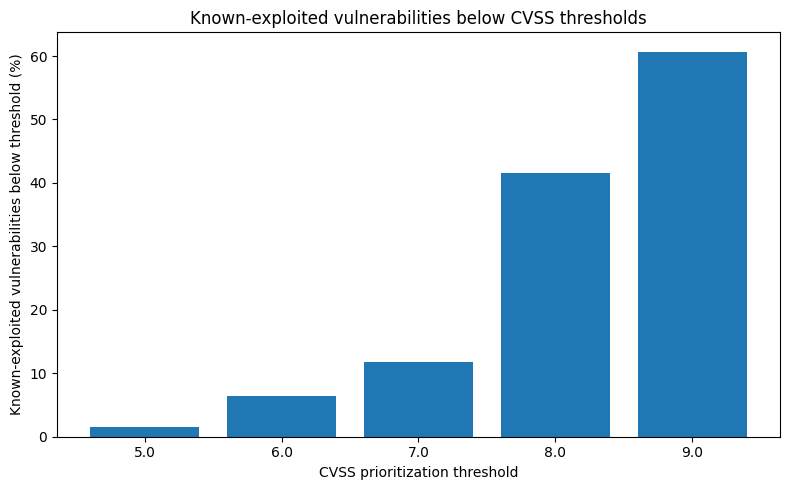

In [13]:
plot_df = threshold_df.sort_values("CVSS priority threshold")

plt.figure(figsize=(8, 5))
plt.bar(
    plot_df["CVSS priority threshold"].astype(str),
    plot_df["Percent below threshold"]
)
plt.xlabel("CVSS prioritization threshold")
plt.ylabel("Known-exploited vulnerabilities below threshold (%)")
plt.title("Known-exploited vulnerabilities below CVSS thresholds")
plt.tight_layout()
plt.show()


## 8. Does the mismatch change over time?

Two time concepts are kept separate:

- **Publication year:** when NVD reports that the CVE was published.
- **KEV added year:** when CISA added the CVE to the KEV catalog.

The publication-year analysis uses the actual NVD `published` timestamp, **not the ZIP filename year**.

Because 2026 is incomplete, it is shown but should not be compared to completed years without that caveat.


In [14]:
THRESHOLD = 9.0

kev_nvd["below_threshold"] = (
    kev_nvd["cvss_score"] < THRESHOLD
)

by_pub_year = (
    kev_nvd.groupby("publication_year")
           .agg(
               known_exploited=("cve", "count"),
               below_threshold=("below_threshold", "sum"),
               median_cvss=("cvss_score", "median")
           )
           .reset_index()
)

by_pub_year["pct_below_threshold"] = (
    100
    * by_pub_year["below_threshold"]
    / by_pub_year["known_exploited"]
).round(1)

by_pub_year["year_status"] = np.where(
    by_pub_year["publication_year"].eq(2026),
    "Incomplete year",
    "Complete year"
)

display(by_pub_year)


,publication_year,known_exploited,below_threshold,median_cvss,pct_below_threshold,year_status
0,2020,136,78,8.8,57.4,Complete year
1,2021,214,146,8.8,68.2,Complete year
2,2022,130,82,8.8,63.1,Complete year
3,2023,164,113,8.5,68.9,Complete year
4,2024,160,91,8.8,56.9,Complete year
5,2025,195,118,8.8,60.5,Complete year
6,2026,139,63,9.3,45.3,Incomplete year


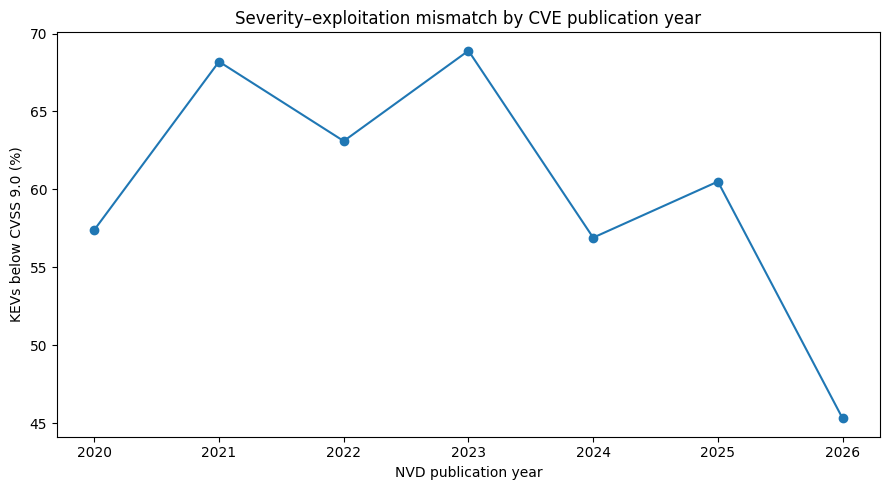

Note: 2026 is an incomplete year.


In [15]:
plt.figure(figsize=(9, 5))
plt.plot(
    by_pub_year["publication_year"],
    by_pub_year["pct_below_threshold"],
    marker="o"
)
plt.xlabel("NVD publication year")
plt.ylabel(f"KEVs below CVSS {THRESHOLD} (%)")
plt.title("Severity–exploitation mismatch by CVE publication year")
plt.xticks(YEARS)
plt.tight_layout()
plt.show()

print("Note: 2026 is an incomplete year.")


In [16]:
by_kev_year = (
    kev_nvd.dropna(subset=["kev_added_year"])
           .groupby("kev_added_year")
           .agg(
               kev_additions=("cve", "count"),
               below_threshold=("below_threshold", "sum"),
               median_cvss=("cvss_score", "median")
           )
           .reset_index()
)

by_kev_year["pct_below_threshold"] = (
    100
    * by_kev_year["below_threshold"]
    / by_kev_year["kev_additions"]
).round(1)

display(by_kev_year)


,kev_added_year,kev_additions,below_threshold,median_cvss,pct_below_threshold
0,2021.0,216,133,8.8,61.6
1,2022.0,174,112,8.8,64.4
2,2023.0,165,116,7.8,70.3
3,2024.0,168,96,8.8,57.1
4,2025.0,222,134,8.8,60.4
5,2026.0,193,100,8.8,51.8


## 9. What do under-prioritized known-exploited vulnerabilities look like?

This section describes characteristics among KEVs below the selected threshold.

Raw vendor and CWE counts are descriptive only. A category can appear frequently simply because it is common in the underlying vulnerability population.


In [17]:
under = kev_nvd[
    kev_nvd["cvss_score"] < THRESHOLD
].copy()

higher = kev_nvd[
    kev_nvd["cvss_score"] >= THRESHOLD
].copy()

print(
    f"Known-exploited vulnerabilities below {THRESHOLD}: "
    f"{len(under):,}"
)
print(
    f"Known-exploited vulnerabilities at/above {THRESHOLD}: "
    f"{len(higher):,}"
)

# Restrict categorical CVSS comparisons to v3.x for consistent definitions.
kev_v3 = kev_nvd[
    kev_nvd["cvss_version"].isin(["3.0", "3.1"])
].copy()

print(f"\nKEVs with CVSS v3.x metrics: {len(kev_v3):,}")

comparison_vars = [
    "attack_vector",
    "attack_complexity",
    "privileges_required",
    "user_interaction",
]

for col in comparison_vars:
    print(f"\n--- {col} (CVSS v3.x only) ---")

    tab = pd.crosstab(
        kev_v3[col],
        kev_v3["below_threshold"],
        margins=True
    )

    display(tab)


Known-exploited vulnerabilities below 9.0: 691
Known-exploited vulnerabilities at/above 9.0: 447

KEVs with CVSS v3.x metrics: 1,137

--- attack_vector (CVSS v3.x only) ---


below_threshold,False,True,All
attack_vector,,,
ADJACENT_NETWORK,1,15,16
LOCAL,0,264,264
NETWORK,445,409,854
PHYSICAL,0,3,3
All,446,691,1137



--- attack_complexity (CVSS v3.x only) ---


below_threshold,False,True,All
attack_complexity,,,
HIGH,7,59,66
LOW,439,632,1071
All,446,691,1137



--- privileges_required (CVSS v3.x only) ---


below_threshold,False,True,All
privileges_required,,,
HIGH,5,71,76
LOW,7,267,274
NONE,434,353,787
All,446,691,1137



--- user_interaction (CVSS v3.x only) ---


below_threshold,False,True,All
user_interaction,,,
NONE,429,464,893
REQUIRED,17,227,244
All,446,691,1137


,CWE,count
0,CWE-787,69
1,CWE-416,59
2,CWE-78,33
3,CWE-22,33
4,CWE-843,24
5,CWE-79,21
6,CWE-94,20
7,CWE-20,19
8,CWE-502,18
9,CWE-200,12


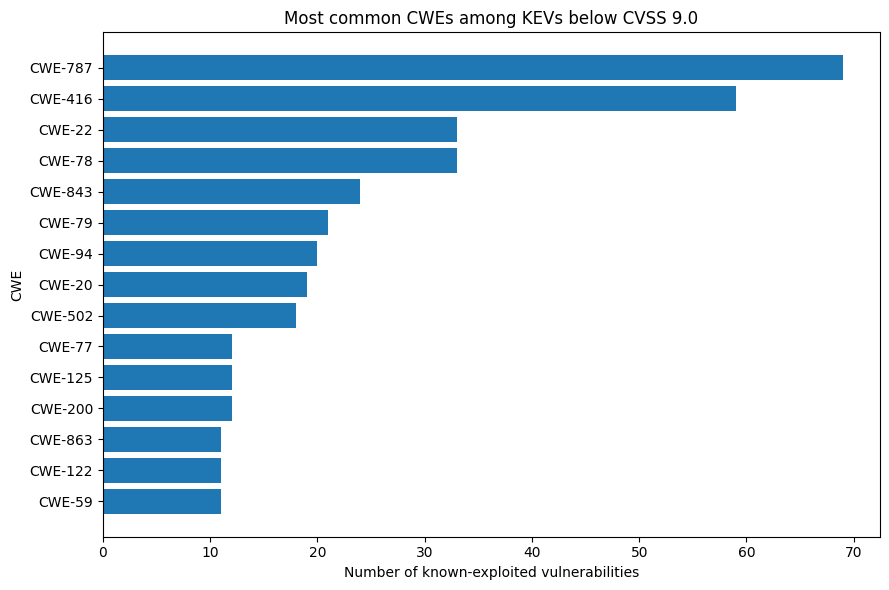

In [18]:
top_cwes_under = (
    under["cwe"]
    .dropna()
    .value_counts()
    .head(15)
    .rename_axis("CWE")
    .reset_index(name="count")
)

display(top_cwes_under)

if len(top_cwes_under):
    plt.figure(figsize=(9, 6))
    temp = top_cwes_under.sort_values("count")
    plt.barh(temp["CWE"], temp["count"])
    plt.xlabel("Number of known-exploited vulnerabilities")
    plt.ylabel("CWE")
    plt.title(f"Most common CWEs among KEVs below CVSS {THRESHOLD}")
    plt.tight_layout()
    plt.show()


In [19]:
vendor_series = None

if "vendorProject" in under.columns:
    vendor_series = under["vendorProject"].fillna(under["vendor"])
else:
    vendor_series = under["vendor"]

top_vendors_under = (
    vendor_series
    .dropna()
    .value_counts()
    .head(15)
    .rename_axis("vendor")
    .reset_index(name="count")
)

display(top_vendors_under)


,vendor,count
0,Microsoft,184
1,Apple,73
2,Google,48
3,Cisco,30
4,Ivanti,19
5,Linux,18
6,Android,15
7,Qualcomm,12
8,VMware,11
9,Samsung,11


## 10. Add EPSS

The EPSS file used here is a **current snapshot dated September 2, 2026**.

Therefore, this section is a **cross-sectional comparison of current EPSS with CVSS and KEV status**. It must not be interpreted as the EPSS score that existed when an older CVE was originally published, prioritized, or exploited.


In [20]:
# EPSS gzip snapshots commonly contain a metadata line before the CSV header.
epss = pd.read_csv(
    EPSS_FILE,
    compression="gzip",
    skiprows=1
)

required_epss = {"cve", "epss"}
missing_epss_cols = required_epss - set(epss.columns)

if missing_epss_cols:
    raise ValueError(
        f"EPSS file is missing required columns: {missing_epss_cols}"
    )

epss["epss"] = pd.to_numeric(
    epss["epss"],
    errors="coerce"
)

if "percentile" in epss.columns:
    epss["percentile"] = pd.to_numeric(
        epss["percentile"],
        errors="coerce"
    )

epss = epss.drop_duplicates("cve")

print("EPSS records:", f"{len(epss):,}")
display(epss.head())


EPSS records: 367,327


,cve,epss,percentile
0,CVE-1999-0001,0.03351,0.87851
1,CVE-1999-0002,0.27858,0.97956
2,CVE-1999-0003,0.24565,0.97723
3,CVE-1999-0004,0.02817,0.85584
4,CVE-1999-0005,0.18415,0.97030


In [21]:
df = df.merge(
    epss,
    on="cve",
    how="left",
    validate="one_to_one"
)

print(
    "NVD study-cohort records with EPSS:",
    f"{df['epss'].notna().sum():,}"
)
print(
    "Matched KEV records with EPSS:",
    f"{df.loc[df['kev'], 'epss'].notna().sum():,}"
)

epss_kev = df[
    df["kev"]
    & df["cvss_score"].notna()
    & df["epss"].notna()
].copy()

epss_kev["below_9"] = epss_kev["cvss_score"] < 9.0

epss_compare = (
    epss_kev.groupby("below_9")["epss"]
            .agg(["count", "mean", "median"])
            .round(4)
)

epss_compare.index = [
    "CVSS >= 9" if not x else "CVSS < 9"
    for x in epss_compare.index
]

display(epss_compare)

print("\nCVSS–EPSS correlation among matched KEVs:")
print(
    epss_kev[["cvss_score", "epss"]]
    .corr(method="spearman")
    .round(3)
)


NVD study-cohort records with EPSS: 232,116
Matched KEV records with EPSS: 1,139


,count,mean,median
CVSS >= 9,447,0.7107,0.9037
CVSS < 9,691,0.3552,0.1876



CVSS–EPSS correlation among matched KEVs:
            cvss_score   epss
cvss_score       1.000  0.401
epss             0.401  1.000


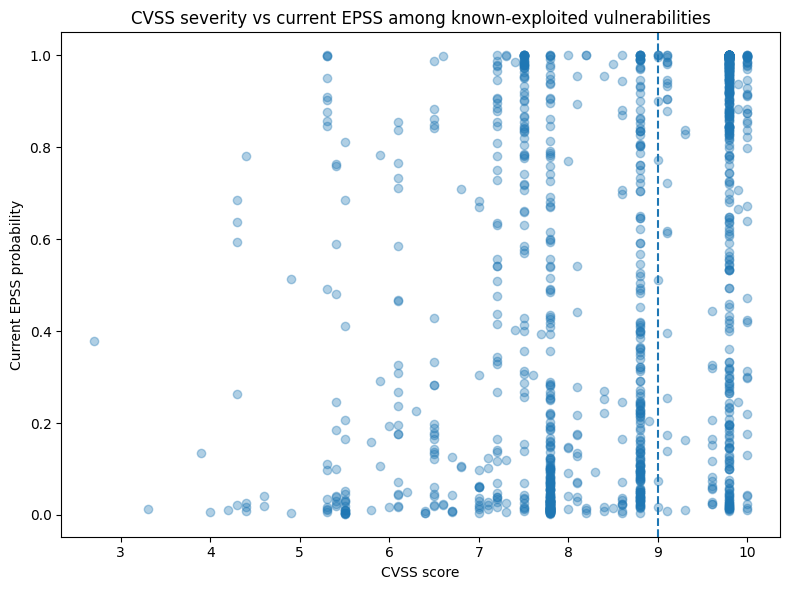

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(
    epss_kev["cvss_score"],
    epss_kev["epss"],
    alpha=0.35
)
plt.axvline(9.0, linestyle="--")
plt.xlabel("CVSS score")
plt.ylabel("Current EPSS probability")
plt.title("CVSS severity vs current EPSS among known-exploited vulnerabilities")
plt.tight_layout()
plt.show()


## 11. Statistical feasibility checks

These are **preliminary feasibility tests**, not the final inferential models.

The outcome here is:

> Among vulnerabilities already known to be exploited, is the CVE below the selected CVSS prioritization threshold?

This is **not** a model predicting exploitation from the full NVD population.

Categorical tests and regression are restricted to CVSS **v3.0/v3.1** records so that version-specific category definitions are not mixed.


In [23]:
from scipy.stats import chi2_contingency

chi_results = []

for col in [
    "attack_vector",
    "attack_complexity",
    "privileges_required",
    "user_interaction",
]:
    tmp = kev_v3[[col, "below_threshold"]].dropna()

    table = pd.crosstab(
        tmp[col],
        tmp["below_threshold"]
    )

    if table.shape[0] >= 2 and table.shape[1] == 2:
        chi2, p, dof, expected = chi2_contingency(table)

        chi_results.append({
            "variable": col,
            "n": len(tmp),
            "chi_square": round(chi2, 2),
            "dof": dof,
            "p_value": p,
            "min_expected_count": round(expected.min(), 2),
        })

chi_df = pd.DataFrame(chi_results)

if len(chi_df):
    chi_df["p_value"] = chi_df["p_value"].map(
        lambda x: f"{x:.4g}"
    )

display(chi_df)


,variable,n,chi_square,dof,p_value,min_expected_count
0,attack_vector,1137,239.08,3,1.508e-51,1.18
1,attack_complexity,1137,22.82,1,1.782e-06,25.89
2,privileges_required,1137,272.21,2,7.75e-60,29.81
3,user_interaction,1137,133.90,1,5.756e-31,95.71


In [24]:
# Preliminary logistic-regression feasibility model.
# Outcome: whether a KNOWN-EXPLOITED CVSS-v3.x vulnerability falls below CVSS 9.
# This is NOT an exploitation prediction model.

try:
    import statsmodels.formula.api as smf

    model_df = kev_v3[
        [
            "below_threshold",
            "publication_year",
            "attack_vector",
            "attack_complexity",
            "privileges_required",
            "user_interaction",
        ]
    ].dropna().copy()

    model_df["below_threshold"] = (
        model_df["below_threshold"].astype(int)
    )

    print("Regression sample size:", f"{len(model_df):,}")
    print(
        "Outcome counts:",
        model_df["below_threshold"].value_counts().to_dict()
    )

    formula = (
        "below_threshold ~ publication_year + "
        "C(attack_vector) + "
        "C(attack_complexity) + "
        "C(privileges_required) + "
        "C(user_interaction)"
    )

    model = smf.logit(
        formula,
        data=model_df
    ).fit(disp=False)

    print(model.summary())

except Exception as e:
    print("Logistic regression could not be fit:", e)
    print(
        "Inspect sample size, missingness, category counts, "
        "and separation before interpreting the model."
    )


Regression sample size: 1,137
Outcome counts: {1: 691, 0: 446}
Logistic regression could not be fit: Singular matrix
Inspect sample size, missingness, category counts, and separation before interpreting the model.


## 12. Sensitivity check: CVSS v3.x only

Because the primary descriptive threshold analysis uses the preferred available CVSS score, this section checks whether the central result changes materially when restricted to CVSS v3.0/v3.1.


In [25]:
kev_v3_thresholds = kev_nvd[
    kev_nvd["cvss_version"].isin(["3.0", "3.1"])
].copy()

sensitivity_results = []

for threshold in thresholds:
    below = (
        kev_v3_thresholds["cvss_score"] < threshold
    ).sum()

    sensitivity_results.append({
        "threshold": threshold,
        "v3_KEVs_below": int(below),
        "v3_KEVs_total": len(kev_v3_thresholds),
        "v3_percent_below": round(
            100 * below / len(kev_v3_thresholds), 1
        ) if len(kev_v3_thresholds) else np.nan,
    })

display(pd.DataFrame(sensitivity_results))


,threshold,v3_KEVs_below,v3_KEVs_total,v3_percent_below
0,9.0,691,1137,60.8
1,8.0,472,1137,41.5
2,7.0,134,1137,11.8
3,6.0,73,1137,6.4
4,5.0,18,1137,1.6


## 13. Feasibility summary

This final table collects the key numbers needed to decide whether the research question has enough data and empirical variation to support the capstone.


In [26]:
usable_cvss_pct = (
    100 * df["cvss_score"].notna().mean()
)

kev_with_cvss = df[
    df["kev"] & df["cvss_score"].notna()
]

kev_below_9_pct = (
    100 * (kev_with_cvss["cvss_score"] < 9).mean()
    if len(kev_with_cvss)
    else np.nan
)

kev_below_7_pct = (
    100 * (kev_with_cvss["cvss_score"] < 7).mean()
    if len(kev_with_cvss)
    else np.nan
)

summary = pd.DataFrame({
    "Feasibility measure": [
        "NVD CVEs published 2020–2026",
        "Unique NVD CVEs in study cohort",
        "NVD records with usable CVSS",
        "Unique KEV CVEs in downloaded catalog",
        "KEV CVEs matched to 2020–2026 NVD cohort",
        "Matched KEVs with usable CVSS",
        "Matched KEVs below CVSS 9.0",
        "Matched KEVs below CVSS 7.0",
        "NVD records with CWE",
        "NVD records with vendor",
        "NVD records with current EPSS",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['cve'].nunique():,}",
        f"{usable_cvss_pct:.1f}%",
        f"{kev['cveID'].nunique():,}",
        f"{df['kev'].sum():,}",
        f"{len(kev_with_cvss):,}",
        f"{kev_below_9_pct:.1f}%",
        f"{kev_below_7_pct:.1f}%",
        f"{100 * df['cwe'].notna().mean():.1f}%",
        f"{100 * df['vendor'].notna().mean():.1f}%",
        f"{100 * df['epss'].notna().mean():.1f}%",
    ]
})

display(summary)


,Feasibility measure,Value
0,NVD CVEs published 2020–2026,"239,942"
1,Unique NVD CVEs in study cohort,"239,942"
2,NVD records with usable CVSS,95.9%
3,Unique KEV CVEs in downloaded catalog,"1,694"
4,KEV CVEs matched to 2020–2026 NVD cohort,"1,139"
5,Matched KEVs with usable CVSS,"1,138"
6,Matched KEVs below CVSS 9.0,60.7%
7,Matched KEVs below CVSS 7.0,11.8%
8,NVD records with CWE,88.2%
9,NVD records with vendor,74.7%


## 14. Decision guide

The project has a strong feasibility signal if the completed notebook shows:

- a substantial number of KEV CVEs matching the 2020–2026 NVD publication cohort;
- a meaningful share of matched KEVs below realistic CVSS thresholds;
- enough year-to-year variation to justify a time component;
- adequate CVSS v3.x characteristic coverage for subgroup analysis;
- enough observations in the below-threshold and at/above-threshold groups for statistical testing;
- useful current EPSS coverage for a clearly labeled cross-sectional comparison.

### Interpretation limits
- KEV is a high-confidence positive indicator of known exploitation, not a complete list of every exploited vulnerability.
- The notebook should not label non-KEV CVEs as confirmed “not exploited.”
- 2026 is incomplete.
- Current EPSS scores should not be interpreted historically.
- Vendor and CWE raw counts should be compared against their underlying prevalence before drawing substantive conclusions.
